IMPORTING LIBRARIES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

DOWNLOAD STOCK DATA

In [ ]:
stock = "RELIANCE.NS"

data = yf.download(
    stock,
    start="2018-01-01",
    end="2024-01-01"
)

print(data.shape)
data.head()

/tmp/ipykernel_7811/3680323274.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

(1481, 5)


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2018-01-01,400.015259,405.709332,399.025937,405.709332,9453202
2018-01-02,400.630859,404.324335,398.542295,401.444307,9499419
2018-01-03,402.235779,407.160403,401.466300,406.720688,13507800
2018-01-04,404.654083,405.313641,402.631471,403.708730,9008932
2018-01-05,405.951202,407.556113,404.632117,405.313658,7441284


DATA VISUALIZATION

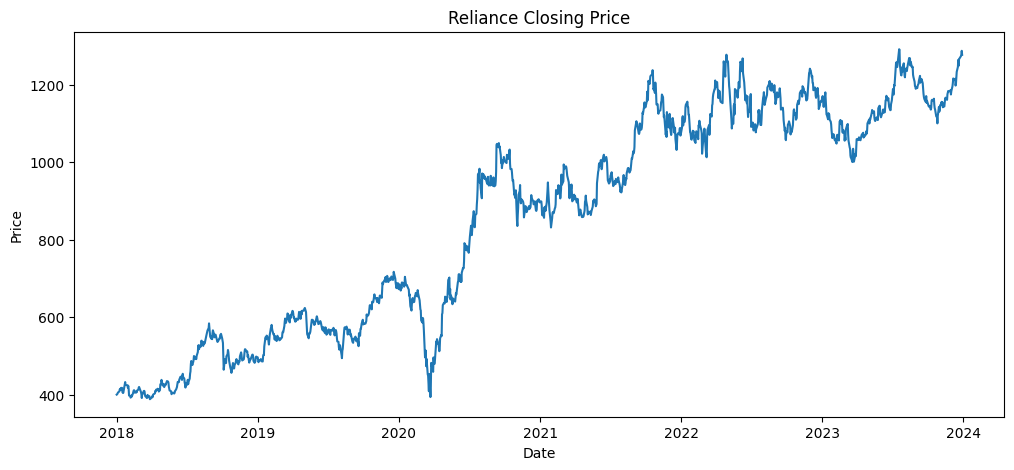

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(data['Close'])

plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

FEATURE ENGINEERING

In [ ]:
data['MA20'] = data['Close'].rolling(window=20).mean()

data['MA50'] = data['Close'].rolling(window=50).mean()

delta = data['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data['RSI'] = 100 - (100 / (1 + rs))

data = data.dropna()

print(data.shape)

(1432, 8)


In [ ]:
features = data[
[
'Close',
'MA20',
'MA50',
'RSI',
'Volume'
]
]

print(features.shape)
features.head()

(1432, 5)


Price,Close,MA20,MA50,RSI,Volume
Ticker,RELIANCE.NS,,,,RELIANCE.NS
Date,,,,,
2018-03-14,408.501526,408.023289,408.942484,49.896538,14724464
2018-03-15,400.916687,407.542920,408.960513,46.007010,12711836
2018-03-16,395.750244,406.760260,408.862900,39.245274,30814962
2018-03-19,393.749603,406.193051,408.693177,36.423604,12630833
2018-03-20,391.243286,405.375214,408.424961,30.163362,15192983


FEATURE SCALING

In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(features)

scaled_close = target_scaler.fit_transform(
    data[['Close']]
)

print(len(scaled_features))
print(len(scaled_close))

1432
1432


SLIDING WINDOW

In [ ]:
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled_features)):

    X.append(
        scaled_features[i-window_size:i]
    )

    y.append(
        scaled_close[i]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1402, 30, 5)
(1402, 1)


TRAIN/TEST SPLIT

In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1121, 30, 5)
(281, 30, 5)
(1121, 1)
(281, 1)


BASELINE MODEL

In [ ]:
baseline_predictions = []

for sample in X_test:

    last_price = sample[-1][0]

    baseline_predictions.append(last_price)

baseline_predictions = np.array(
    baseline_predictions
)

baseline_predictions = baseline_predictions.reshape(-1,1)

baseline_predictions_actual = target_scaler.inverse_transform(
    baseline_predictions
)

y_test_actual = target_scaler.inverse_transform(
    y_test
)

print(baseline_predictions_actual.shape)
print(y_test_actual.shape)

(281, 1)
(281, 1)


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    y_test_actual,
    baseline_predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        baseline_predictions_actual
    )
)

print("BASELINE MAE:", mae)
print("BASELINE RMSE:", rmse)

BASELINE MAE: 9.562572112711303
BASELINE RMSE: 12.662673715321723


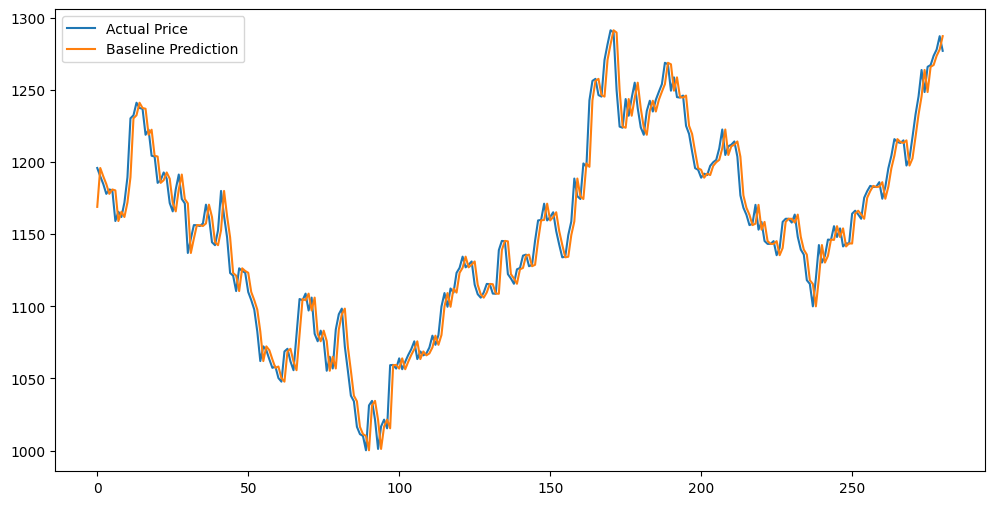

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    baseline_predictions_actual,
    label="Baseline Prediction"
)

plt.legend()

plt.show()

LINEAR REGRESSION

In [ ]:
X_train_lr = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_lr = X_test.reshape(
    X_test.shape[0],
    -1
)

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train_lr,
    y_train
)

lr_predictions = lr_model.predict(
    X_test_lr
)

lr_predictions_actual = target_scaler.inverse_transform(
    lr_predictions
)

mae = mean_absolute_error(
    y_test_actual,
    lr_predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lr_predictions_actual
    )
)

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)

Linear Regression MAE: 10.404474321095012
Linear Regression RMSE: 13.551656946489707


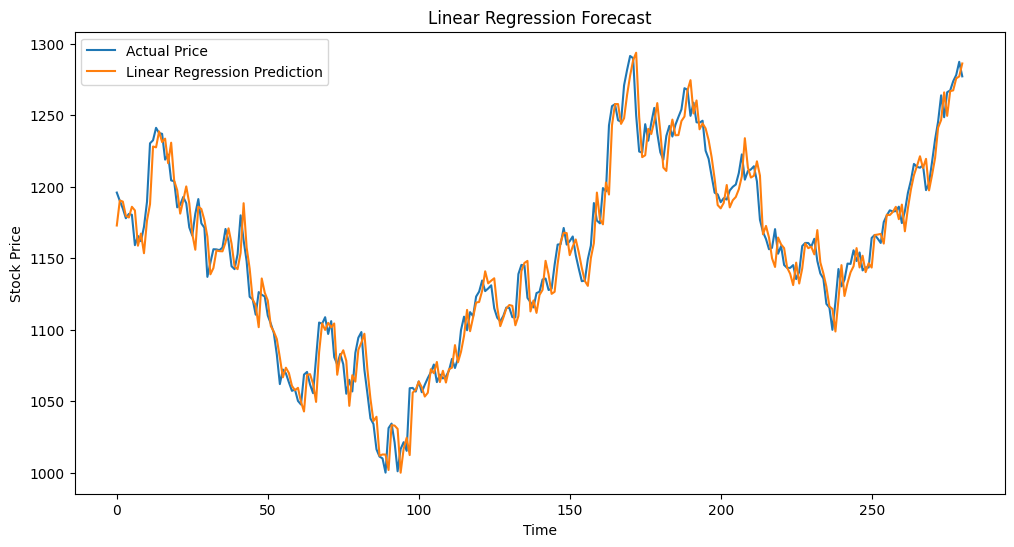

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    lr_predictions_actual,
    label="Linear Regression Prediction"
)

plt.title("Linear Regression Forecast")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

LSTM

In [ ]:

import tensorflow as tf

print(tf.__version__)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(30,5)
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

2.20.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0366 - val_loss: 0.0027
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0058 - val_loss: 0.0018
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0042 - val_loss: 0.0018
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0034 - val_loss: 0.0022
Epoch 8/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0031 - val_loss: 0.0015
Epoch 9/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 10/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 11/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 12/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0

In [ ]:
lstm_predictions = model.predict(
    X_test
)

lstm_predictions_actual = target_scaler.inverse_transform(
    lstm_predictions
)

mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions_actual
    )
)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
LSTM MAE: 14.579215161740992
LSTM RMSE: 18.58455384656766


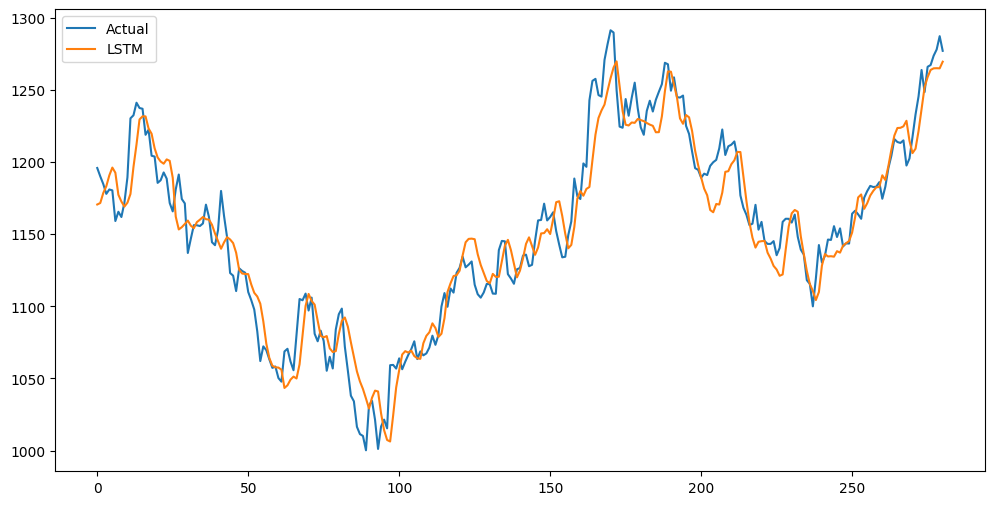

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    lstm_predictions_actual,
    label="LSTM"
)

plt.legend()

plt.show()

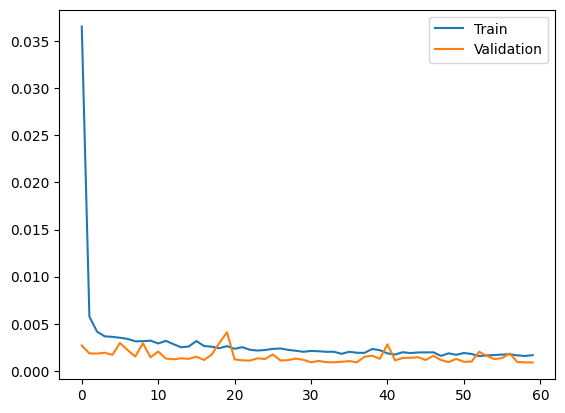

In [ ]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(
    ['Train','Validation']
)

plt.show()

In [ ]:
model.save("stock_lstm_model_v1.h5")

In [ ]:

from google.colab import files
files.download("stock_lstm_model_v1.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("stock_lstm_model.keras")

In [ ]:
from google.colab import files
files.download("stock_lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(lr_model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [ ]:
from google.colab import files
files.download("linear_regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>